In [16]:
import pandas as pd
import pathlib
import rootutils
import torch
import tqdm
import numpy as np
import seaborn as sns
import colorcet as cc
import sklearn

rootutils.setup_root(".", indicator=".project-root", pythonpath=True)
root = pathlib.Path(rootutils.find_root("."))

from torch.nn import functional as F
from matplotlib import pyplot as plt

from src.core.data.soundscape_embeddings import SoundscapeEmbeddingsDataModule
from src.core.models.mil_species_detector import MILSpeciesDetector

scope = "SO_UK"
model_name = "wanted-pencil"

model_path = pathlib.Path(f"/its/home/kag25/models/v3/bayesian_species_detectors/{model_name}_{scope}.ckpt")
model = MILSpeciesDetector.load_from_checkpoint(model_path)
features = pd.read_parquet(f"/its/home/kag25/data/soundscape_vae_embeddings/{model_name}/{scope}/val/features.parquet").reset_index()

/its/home/kag25/projects/ecolistening/interpretable_bioacoustic_classifiers/.venv/lib/python3.10/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental

Bayesian logistic regression allows us to express uncertainty about the model parameters, we infer a posterior distribution over the model weights. There isn't a conjugate prior for the likelihood in logistic regression. A prior is defined as an isotropic Gaussian and the MacKay approximation is made for the posterior.



In [17]:
print(model.classifiers.weight_log_var.size(1))

128


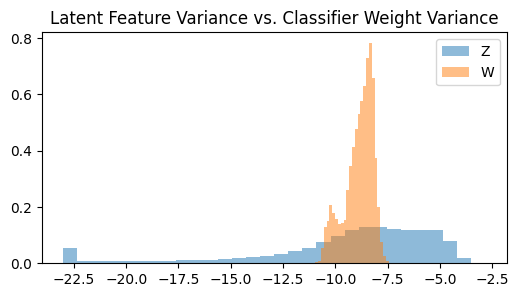

In [34]:
fig, ax = plt.subplots(figsize=(6, 3))
z_log_var = features.loc[:, [f"z_log_var_{i}" for i in range(128)]].melt().drop("variable", axis=1)
ax.hist(z_log_var, bins=30, density=True, label="Z", alpha=0.5)
ax.set_title("Latent Feature Variance vs. Classifier Weight Variance")
w_log_var = model.classifiers.weight_log_var.detach().numpy().flatten()
ax.hist(w_log_var, bins=30, density=True, label="W", alpha=0.5)
ax.legend()
plt.show()


In [3]:
data = list(zip(model.target_names, *model.classifiers.weight_log_var.exp().t().detach().cpu().numpy()))
species_weight_var = pd.DataFrame(data=data, columns=["species_name", *[i for i in range(model.classifiers.weight_log_var.size(1))]])
species_weight_var = species_weight_var.reset_index()
species_weight_var.head()

,index,species_name,0,1,2,3,4,5,6,7,...,118,119,120,121,122,123,124,125,126,127
0,0,Cyanistes caeruleus_Eurasian Blue Tit,0.000083,0.000073,0.000074,0.000128,0.000094,0.000129,0.000084,0.000076,...,0.000102,0.000096,0.000142,0.000099,0.000093,0.000126,0.000076,0.000082,0.000069,0.000098
1,1,Dendrocopos major_Great Spotted Woodpecker,0.000218,0.000240,0.000255,0.000218,0.000286,0.000230,0.000270,0.000199,...,0.000223,0.000246,0.000244,0.000245,0.000281,0.000198,0.000210,0.000255,0.000217,0.000164
2,2,Poecile palustris_Marsh Tit,0.000284,0.000283,0.000407,0.000409,0.000262,0.000294,0.000212,0.000269,...,0.000277,0.000427,0.000320,0.000300,0.000357,0.000281,0.000285,0.000418,0.000299,0.000367
3,3,Strix aluco_Tawny Owl,0.000147,0.000193,0.000334,0.000241,0.000219,0.000185,0.000208,0.000203,...,0.000153,0.000321,0.000161,0.000240,0.000173,0.000274,0.000183,0.000352,0.000175,0.000268
4,4,Chloris chloris_European Greenfinch,0.000189,0.000210,0.000246,0.000146,0.000162,0.000223,0.000223,0.000241,...,0.000210,0.000250,0.000283,0.000152,0.000196,0.000163,0.000171,0.000286,0.000159,0.000244


In [4]:
scores = pd.read_parquet(root / "dump" / "mil_detector_test" / "val_scores.parquet").drop([
    'run_id', 'seed',
    'attention', 'classifiers', 'clf_regulariser',
    'attn_regulariser', 'beta', 'gamma_clf', 'gamma_attn',
    'label_smoothing', 'clf_learning_rate', 'attn_learning_rate',
    'train_sample_size', 'eval_sample_size', 'epoch'
], axis=1)
scores = scores.iloc[scores["AP"].argsort()[::-1]]
order = scores.species_name.unique()

In [5]:
scores.head()

,species_name,AP,auROC,train_label_counts,model,scope
41,Turdus merula_Eurasian Blackbird,0.891756,0.906530,588,wanted-pencil,SO_UK
10,Erithacus rubecula_European Robin,0.861697,0.875205,578,wanted-pencil,SO_UK
17,Troglodytes hiemalis_Winter Wren,0.784420,0.829821,556,wanted-pencil,SO_UK
28,Phylloscopus collybita_Common Chiffchaff,0.772244,0.869770,351,wanted-pencil,SO_UK
42,Turdus philomelos_Song Thrush,0.744636,0.865068,426,wanted-pencil,SO_UK


In [6]:
df = scores.merge(species_weight_var, on="species_name", how="inner").drop("index", axis=1)
df = df.set_index(["species_name", "AP", "auROC", "train_label_counts", "model", "scope"])
df.head()

,,,,,,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
species_name,AP,auROC,train_label_counts,model,scope,,,,,,,,,,,,,,,,,,,,,
Turdus merula_Eurasian Blackbird,0.891756,0.906530,588,wanted-pencil,SO_UK,0.000038,0.000042,0.000052,0.000044,0.000049,0.000048,0.000039,0.000044,0.000040,0.000053,...,0.000038,0.000047,0.000036,0.000044,0.000046,0.000051,0.000046,0.000041,0.000045,0.000041
Erithacus rubecula_European Robin,0.861697,0.875205,578,wanted-pencil,SO_UK,0.000034,0.000030,0.000072,0.000064,0.000036,0.000026,0.000030,0.000025,0.000035,0.000044,...,0.000024,0.000041,0.000037,0.000031,0.000029,0.000042,0.000029,0.000054,0.000032,0.000029
Troglodytes hiemalis_Winter Wren,0.784420,0.829821,556,wanted-pencil,SO_UK,0.000020,0.000025,0.000052,0.000039,0.000033,0.000031,0.000028,0.000028,0.000026,0.000027,...,0.000027,0.000028,0.000023,0.000026,0.000029,0.000028,0.000025,0.000058,0.000022,0.000027
Phylloscopus collybita_Common Chiffchaff,0.772244,0.869770,351,wanted-pencil,SO_UK,0.000040,0.000038,0.000045,0.000047,0.000050,0.000049,0.000037,0.000037,0.000038,0.000036,...,0.000043,0.000045,0.000114,0.000056,0.000051,0.000050,0.000044,0.000049,0.000040,0.000042
Turdus philomelos_Song Thrush,0.744636,0.865068,426,wanted-pencil,SO_UK,0.000026,0.000032,0.000041,0.000062,0.000034,0.000023,0.000024,0.000027,0.000023,0.000039,...,0.000031,0.000026,0.000035,0.000029,0.000030,0.000028,0.000031,0.000068,0.000027,0.000029


In [10]:
long_df = df.melt(var_name="weight_index", value_name="weight_var", ignore_index=False).reset_index()
long_df.head()
long_df["weight_log_var"] = np.log(long_df["weight_var"])

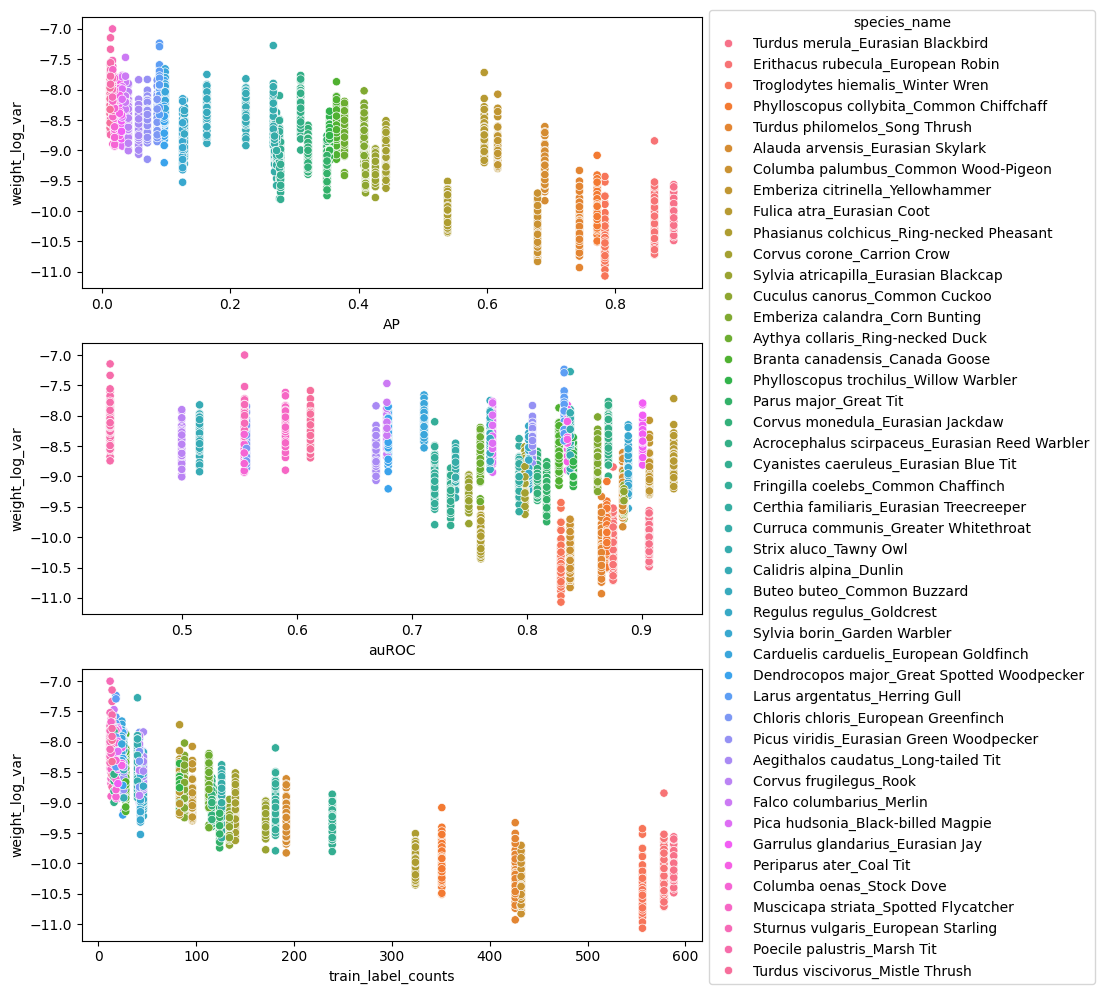

In [28]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, figsize=(8, 12))
sns.scatterplot(data=long_df, x="AP", hue="species_name", y="weight_log_var", hue_order=order, ax=ax1)
sns.move_legend(ax1, "upper left", bbox_to_anchor=(1, 1))
sns.scatterplot(data=long_df, x="auROC", hue="species_name", y="weight_log_var", hue_order=order, ax=ax2, legend=False)
sns.scatterplot(data=long_df, x="train_label_counts", hue="species_name", y="weight_log_var", hue_order=order, ax=ax3, legend=False)
sns.move_legend(ax1, "upper left", bbox_to_anchor=(1, 1.05))
plt.show()

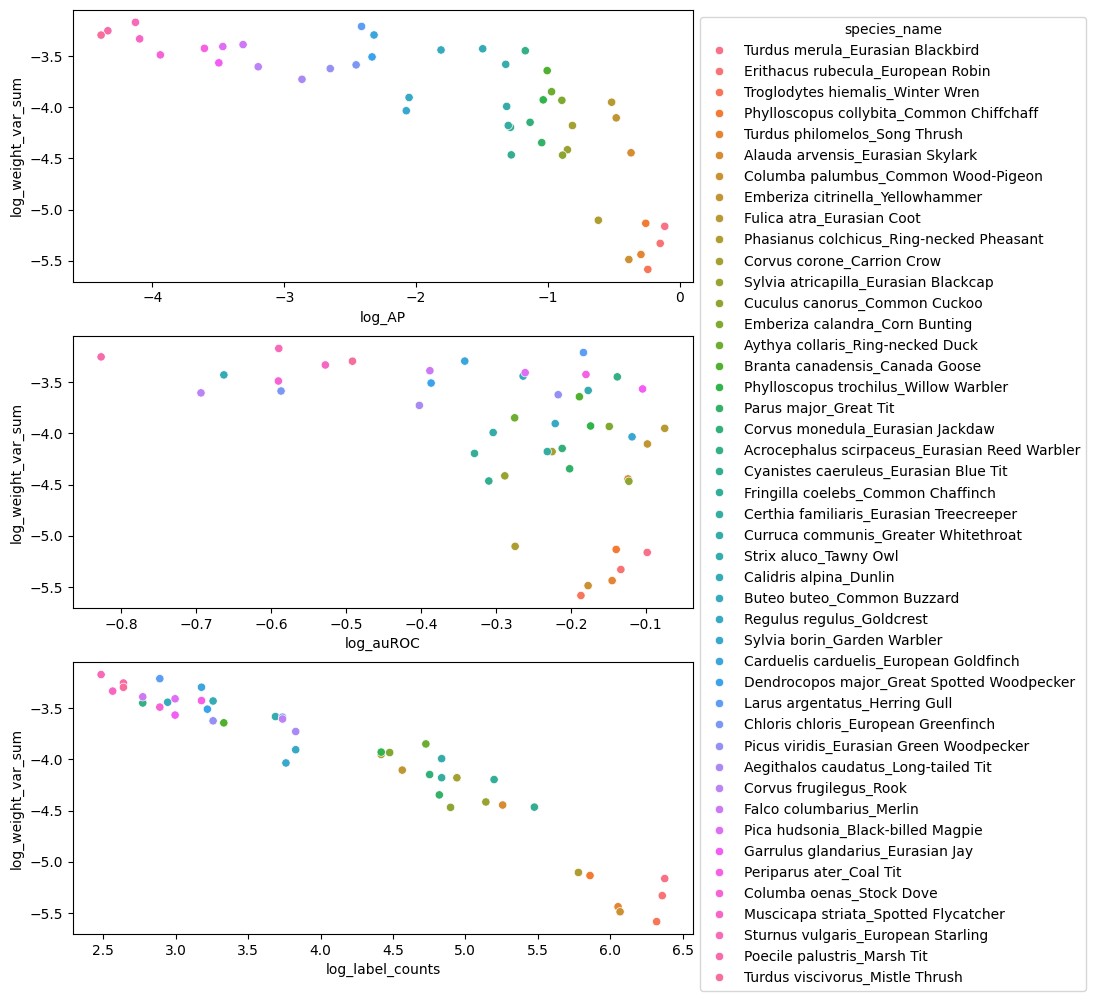

In [52]:
df1 = df.sum(axis=1).reset_index().rename(columns={0: "weight_var_sum"})
df1["log_label_counts"] = np.log(df1["train_label_counts"])
df1["log_weight_var_sum"] = np.log(df1["weight_var_sum"])
df1["neg_log_weight_var_sum"] = -np.log(df1["weight_var_sum"])
df1["log_AP"] = np.log(df1["AP"])
df1["log_auROC"] = np.log(df1["auROC"])

fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, figsize=(8, 12))
sns.scatterplot(data=df1, x="log_AP", hue="species_name", y="log_weight_var_sum", hue_order=order, ax=ax1)
sns.move_legend(ax1, "upper left", bbox_to_anchor=(1, 1))
sns.scatterplot(data=df1, x="log_auROC", hue="species_name", y="log_weight_var_sum", hue_order=order, ax=ax2, legend=False)
sns.scatterplot(data=df1, x="log_label_counts", hue="species_name", y="log_weight_var_sum", hue_order=order, ax=ax3, legend=False)
sns.move_legend(ax1, "upper left", bbox_to_anchor=(1, 1))
plt.show()

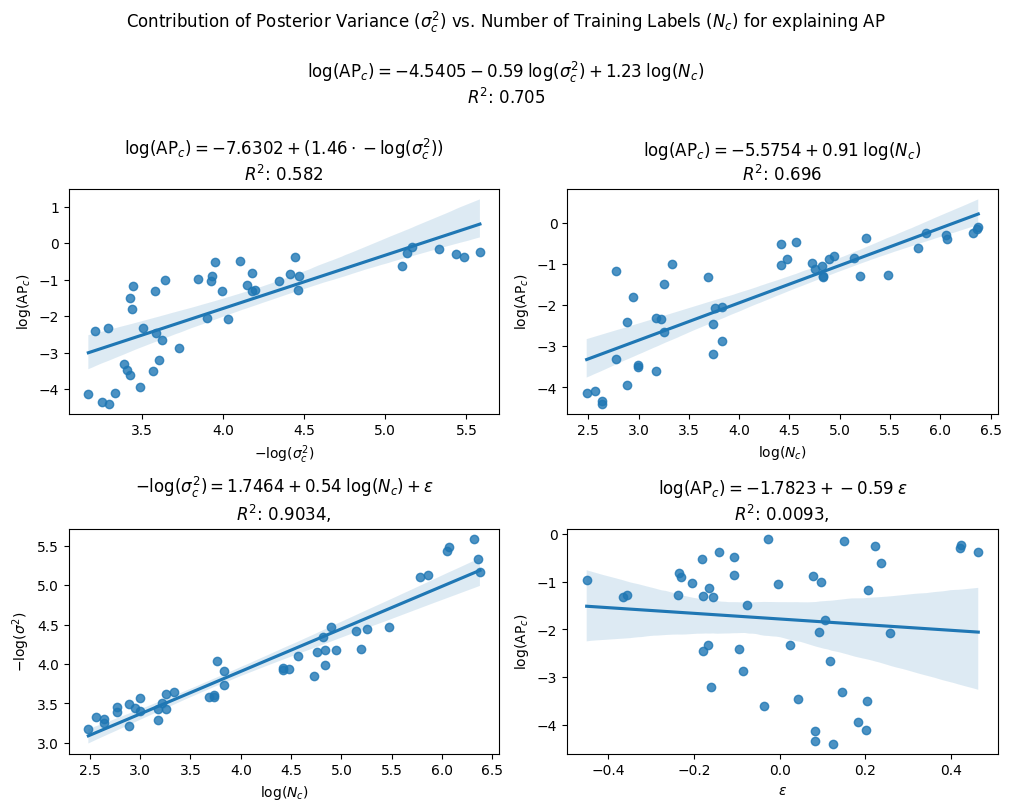

In [154]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), constrained_layout=True)

p = 4

X, y = df1[["neg_log_weight_var_sum", "log_label_counts"]], df1["log_AP"]
reg = sklearn.linear_model.LinearRegression()
reg.fit(X, y)
fig.suptitle((
    "Contribution of Posterior Variance ($\sigma_c^2$) vs. Number of Training Labels ($N_c$) for explaining AP\n\n"
    rf"$\log(\text{{AP}}_c) = {np.format_float_positional(reg.intercept_, precision=p)}"
    rf"{np.format_float_positional(reg.coef_[0], precision=2)}\;\log(\sigma_c^2) + "
    rf"{np.format_float_positional(reg.coef_[1], precision=2)}\;\log(N_c)$"
    "\n"
    rf"$R^2$: {np.format_float_positional(reg.score(X, y), precision=3)}"
    "\n"
))

# correlation between the posterior variance and the average precision
# how much of the variance in the scores is explained by the posterior variance
X, y = df1[["neg_log_weight_var_sum"]], df1["log_AP"]
reg = sklearn.linear_model.LinearRegression()
reg.fit(X, y)
sns.regplot(data=df1, x="neg_log_weight_var_sum", y="log_AP", ax=ax1)
ax1.set_title((
    rf"$\log(\text{{AP}}_c) = {np.format_float_positional(reg.intercept_, precision=p)} +"
    rf"({np.format_float_positional(reg.coef_[0], precision=2)}\cdot -\log(\sigma_c^2))$"
    "\n"
    rf"$R^2$: {np.format_float_positional(reg.score(X, y), precision=3)}"
))
ax1.set_xlabel(r"$-\log(\sigma_c^2)$")
ax1.set_ylabel(r"$\log(\mathrm{AP}_c)$")

# correlation between the label counts and the average precision
# how much of the variance in the scores is explained by the the number of training labels
X, y = df1[["log_label_counts"]], df1["log_AP"]
reg = sklearn.linear_model.LinearRegression()
reg.fit(X, y)
sns.regplot(data=df1, x="log_label_counts", y="log_AP", ax=ax2)
ax2.set_title((
    rf"$\log(\text{{AP}}_c) = {np.format_float_positional(reg.intercept_, precision=p)} +"
    rf"{np.format_float_positional(reg.coef_[0], precision=2)}\;\log(N_c)$"
    "\n"
    rf"$R^2$: {np.format_float_positional(reg.score(X, y), precision=3)}"
))
ax2.set_xlabel(r"$\log(N_c)$")
ax2.set_ylabel(r"$\log(\mathrm{AP}_c)$")

# since it appears from comparing the first regression R2 with the previous two,
# it appears the number of labels explain most of the correlation.
# how much does the posterior variance actually contribute
X1, X2, y = df1[["log_label_counts"]], df1["neg_log_weight_var_sum"], df1[["log_AP"]]
reg = sklearn.linear_model.LinearRegression()
reg.fit(X1, X2)
sns.regplot(data=df1, x="log_label_counts", y="neg_log_weight_var_sum", ax=ax3)
ax3.set_title((
    rf"$-\log(\sigma_c^2) = {np.format_float_positional(reg.intercept_, precision=p)} +"
    rf"{np.format_float_positional(reg.coef_[0], precision=2)}\;\log(N_c) + \epsilon$"
    "\n"
    rf"$R^2$: {np.format_float_positional(reg.score(X1, X2), precision=p)}, "
))
ax3.set_xlabel(r"$\log(N_c)$")
ax3.set_ylabel(r"$-\log(\sigma^2)$")

df1["variance_residual"] = X2 - reg.predict(X1)
X3 = df1[["variance_residual"]]
reg = sklearn.linear_model.LinearRegression()
reg.fit(X3, y)
sns.regplot(data=df1, x="variance_residual", y="log_AP", ax=ax4)
ax4.set_title((
    rf"$\log(\text{{AP}}_c) = {np.format_float_positional(reg.intercept_, precision=p)} +"
    rf"{np.format_float_positional(reg.coef_[0], precision=2)}\;\epsilon$"
    "\n"
    rf"$R^2$: {np.format_float_positional(reg.score(X3, y), precision=p)}, "
))
ax4.set_xlabel(r"$\epsilon$")
ax4.set_ylabel(r"$\log(\mathrm{AP}_c)$")

plt.savefig(root / "dump" / "posterior-variance-contribution_log.pdf", format="pdf")
plt.show()

**Verdict**: The class-level posterior variance mostly acts as a learned proxy for training label count. It does not appear to provide substantial additional information about class performance once class frequency is known

In [149]:
df = pd.read_parquet("/its/home/kag25/experiments/v3/species_detectors/val.parquet/wanted-pencil-SO_UK.parquet").reset_index()
df.head()

,dataloader_idx,file_i,sample_i,t,species_i,y_t_prob,mu_a,sigma_sq_a,attn_w
0,1,0,0,0,0,0.775308,1.250709,0.050335,0.004190
1,1,0,0,0,1,0.000377,-8.090384,0.135353,0.002669
2,1,0,0,0,2,0.009789,-4.764565,0.165815,0.016705
3,1,0,0,0,3,0.000593,-7.605214,0.121874,0.006515
4,1,0,0,0,4,0.000023,-10.914970,0.118920,0.004048


In [150]:
df["alpha_sigma_sq"] = (df["sigma_sq_a"] * df["attn_w"])
df1 = df.groupby(["file_i", "sample_i", "species_i"])["alpha_sigma_sq"].sum().reset_index().groupby(["file_i", "species_i"])["alpha_sigma_sq"].mean()

file_i  species_i
0       0            0.060241
        1            0.141570
        2            0.173818
        3            0.136983
        4            0.155769
                       ...   
2021    40           0.059451
        41           0.024962
        42           0.018626
        43           0.131530
        44           0.109094
Name: alpha_sigma_sq, Length: 14580, dtype: float64

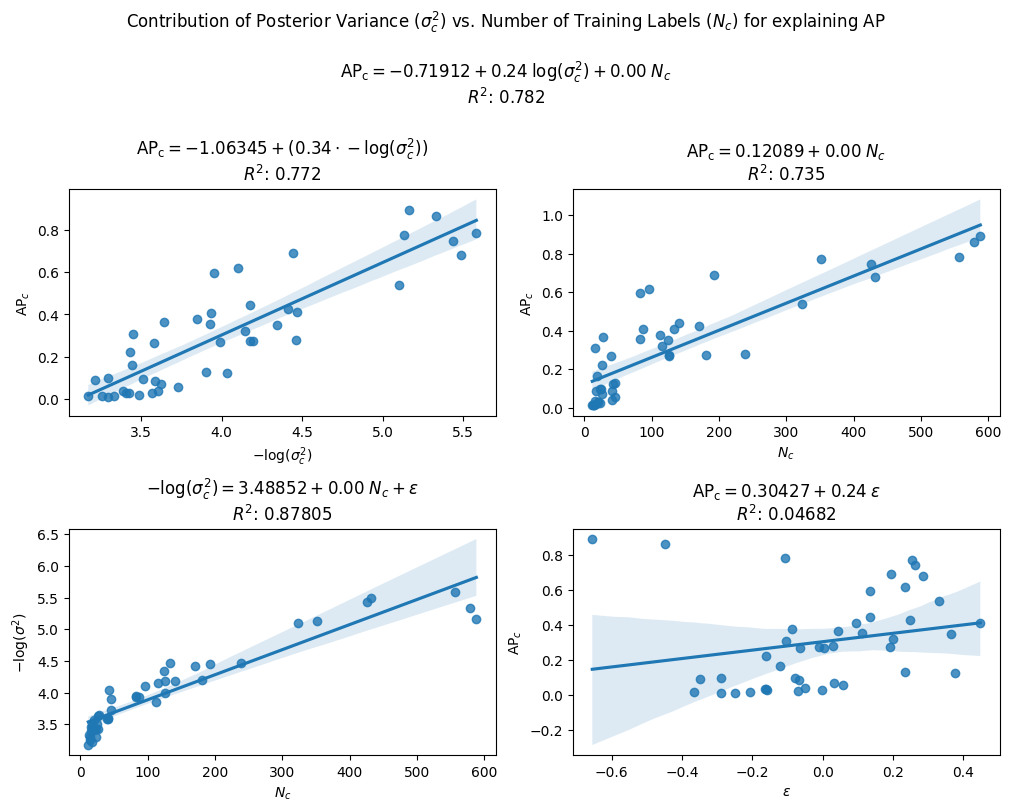

In [171]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), constrained_layout=True)

p = 5

X, y = df1[["neg_log_weight_var_sum", "train_label_counts"]], df1["AP"]
reg = sklearn.linear_model.LinearRegression()
reg.fit(X, y)
fig.suptitle((
    "Contribution of Posterior Variance ($\sigma_c^2$) vs. Number of Training Labels ($N_c$) for explaining AP\n\n"
    rf"$\mathrm{{AP_c}} = {np.format_float_positional(reg.intercept_, precision=p)} + "
    rf"{np.format_float_positional(reg.coef_[0], precision=2)}\;\log(\sigma_c^2) + "
    rf"{np.format_float_positional(reg.coef_[1], precision=2)}\;N_c$"
    "\n"
    rf"$R^2$: {np.format_float_positional(reg.score(X, y), precision=3)}"
    "\n"
))

# correlation between the posterior variance and the average precision
# how much of the variance in the scores is explained by the posterior variance
X, y = df1[["neg_log_weight_var_sum"]], df1["AP"]
reg = sklearn.linear_model.LinearRegression()
reg.fit(X, y)
sns.regplot(data=df1, x="neg_log_weight_var_sum", y="AP", ax=ax1)
ax1.set_title((
    rf"$\mathrm{{AP_c}} = {np.format_float_positional(reg.intercept_, precision=p)} +"
    rf"({np.format_float_positional(reg.coef_[0], precision=2)}\cdot -\log(\sigma_c^2))$"
    "\n"
    rf"$R^2$: {np.format_float_positional(reg.score(X, y), precision=3)}"
))
ax1.set_xlabel(r"$-\log(\sigma_c^2)$")
ax1.set_ylabel(r"$\mathrm{AP}_c$")

# correlation between the label counts and the average precision
# how much of the variance in the scores is explained by the the number of training labels
X, y = df1[["train_label_counts"]], df1["AP"]
reg = sklearn.linear_model.LinearRegression()
reg.fit(X, y)
sns.regplot(data=df1, x="train_label_counts", y="AP", ax=ax2)
ax2.set_title((
    rf"$\mathrm{{AP_c}} = {np.format_float_positional(reg.intercept_, precision=p)} +"
    rf"{np.format_float_positional(reg.coef_[0], precision=2)}\;N_c$"
    "\n"
    rf"$R^2$: {np.format_float_positional(reg.score(X, y), precision=3)}"
))
ax2.set_xlabel(r"$N_c$")
ax2.set_ylabel(r"$\mathrm{AP}_c$")

# since it appears from comparing the first regression R2 with the previous two,
# it appears the number of labels explain most of the correlation.
# how much does the posterior variance actually contribute
X1, X2, y = df1[["train_label_counts"]], df1["neg_log_weight_var_sum"], df1[["AP"]]
reg = sklearn.linear_model.LinearRegression()
reg.fit(X1, X2)
sns.regplot(data=df1, x="train_label_counts", y="neg_log_weight_var_sum", ax=ax3)
ax3.set_title((
    rf"$-\log(\sigma_c^2) = {np.format_float_positional(reg.intercept_, precision=p)} +"
    rf"{np.format_float_positional(reg.coef_[0], precision=2)}\;N_c + \epsilon$"
    "\n"
    rf"$R^2$: {np.format_float_positional(reg.score(X1, X2), precision=p)}"
))
ax3.set_xlabel(r"$N_c$")
ax3.set_ylabel(r"$-\log(\sigma^2)$")

df1["variance_residual"] = X2 - reg.predict(X1)
X3 = df1[["variance_residual"]]
reg = sklearn.linear_model.LinearRegression()
reg.fit(X3, y)
sns.regplot(data=df1, x="variance_residual", y="AP", ax=ax4)
ax4.set_title((
    rf"$\mathrm{{AP_c}} = {np.format_float_positional(reg.intercept_, precision=p)} +"
    rf"{np.format_float_positional(reg.coef_[0], precision=2)}\;\epsilon$"
    "\n"
    rf"$R^2$: {np.format_float_positional(reg.score(X3, y), precision=p)}"
))
ax4.set_xlabel(r"$\epsilon$")
ax4.set_ylabel(r"$\mathrm{AP}_c$")

# plt.savefig(root / "dump" / "posterior-variance-contribution.pdf", format="pdf")
plt.show()

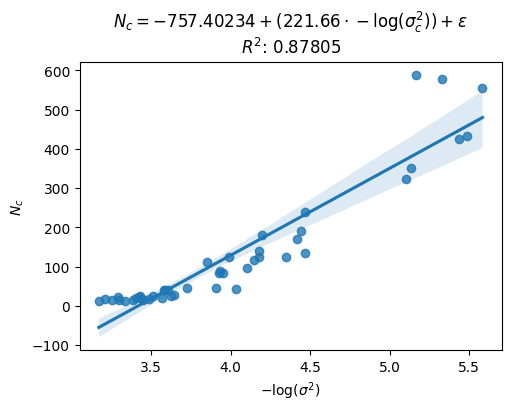

In [172]:
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)

X1, X2, y = df1[["neg_log_weight_var_sum"]], df1["train_label_counts"], df1[["AP"]]
reg = sklearn.linear_model.LinearRegression()
reg.fit(X1, X2)
sns.regplot(data=df1, x="neg_log_weight_var_sum", y="train_label_counts", ax=ax)
ax.set_title((
    rf"$N_c = {np.format_float_positional(reg.intercept_, precision=p)} +"
    rf"({np.format_float_positional(reg.coef_[0], precision=2)}\cdot -\log(\sigma_c^2)) + \epsilon$"
    "\n"
    rf"$R^2$: {np.format_float_positional(reg.score(X1, X2), precision=p)}"
))
ax.set_ylabel(r"$N_c$")
ax.set_xlabel(r"$-\log(\sigma^2)$")
plt.show()

Aggregate across all model seeds

/its/home/kag25/projects/ecolistening/interpretable_bioacoustic_classifiers/.venv/lib/python3.10/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental

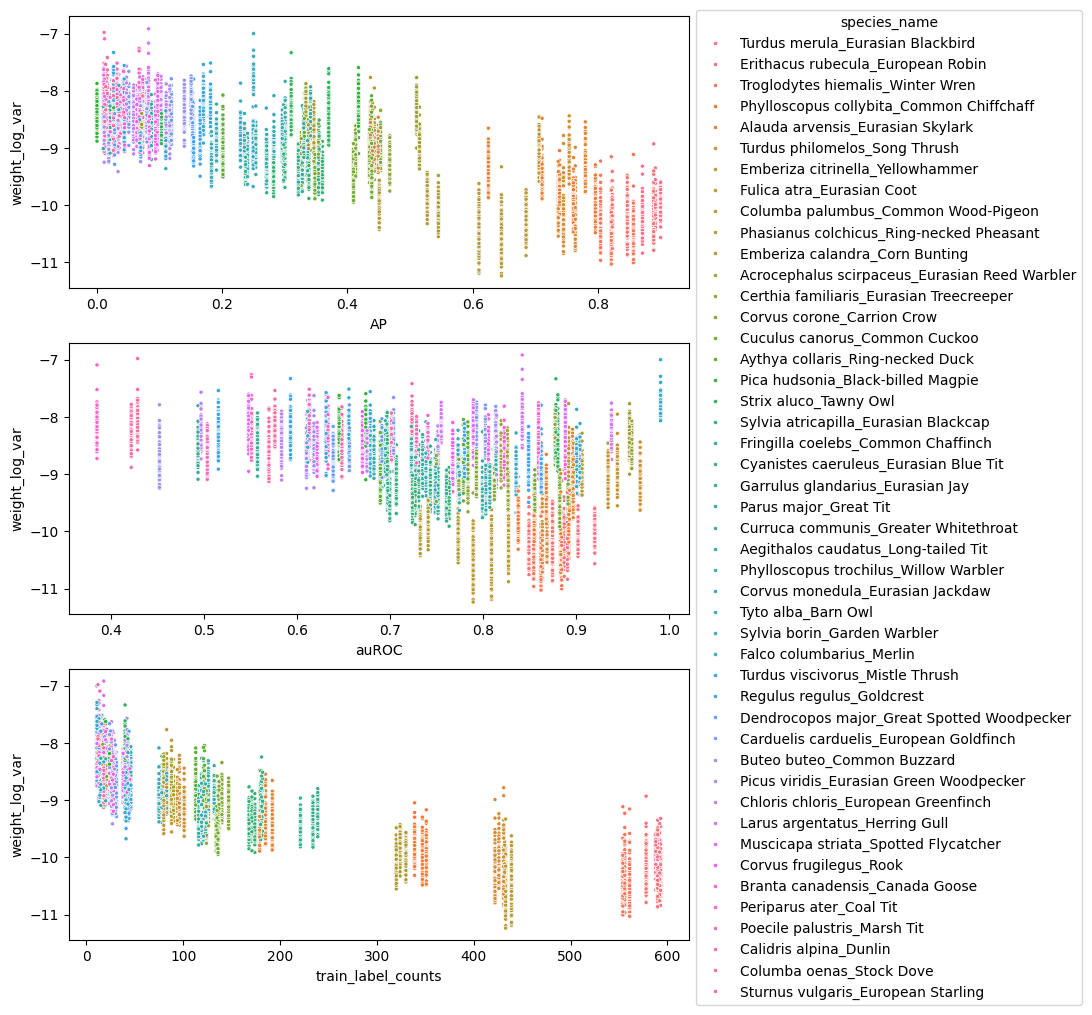

/its/home/kag25/projects/ecolistening/interpretable_bioacoustic_classifiers/.venv/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


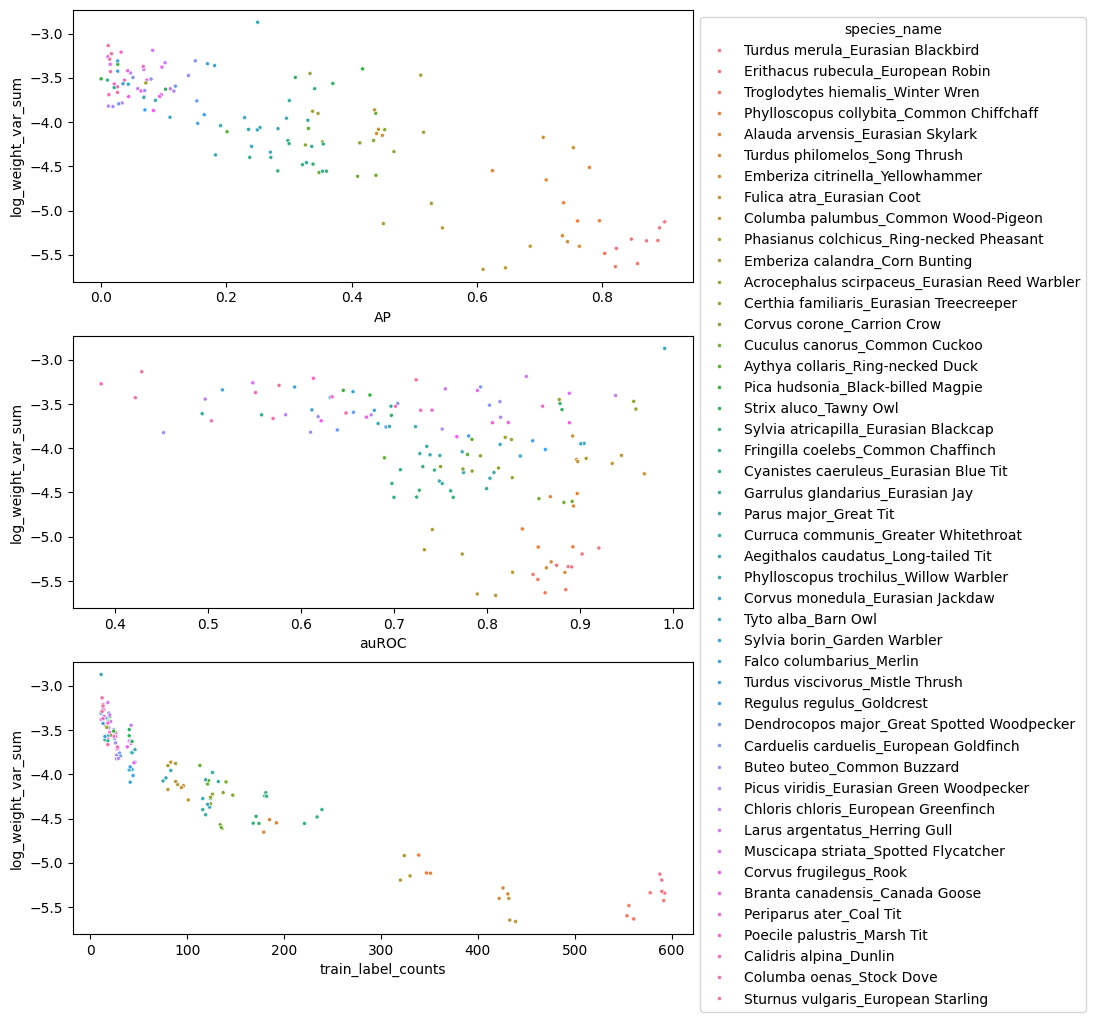

Contribution of Posterior Variance ($\sigma_c^2$) vs. Number of Training Labels ($N_c$) for explaining AP

$\mathrm{AP_c} = -0.47650526 + 0.16535802\;\log(\sigma_c^2) + 0.00077388\;N_c$
$R^2$: 0.760

$\mathrm{AP_c} = -1.0755663-0.3376275\;\log(\sigma_c^2)$
$R^2$: 0.727
$\mathrm{AP_c} = 0.11278112 +0.00140640\;N_c$
$R^2$: 0.734
$\log(\sigma_c^2) = -3.56370012-0.00382513\;N_c + \epsilon$
$R^2$: 0.85148870
$\mathrm{AP_c} = 0.29456871-0.16535802\;\epsilon$
$R^2$: 0.02589873


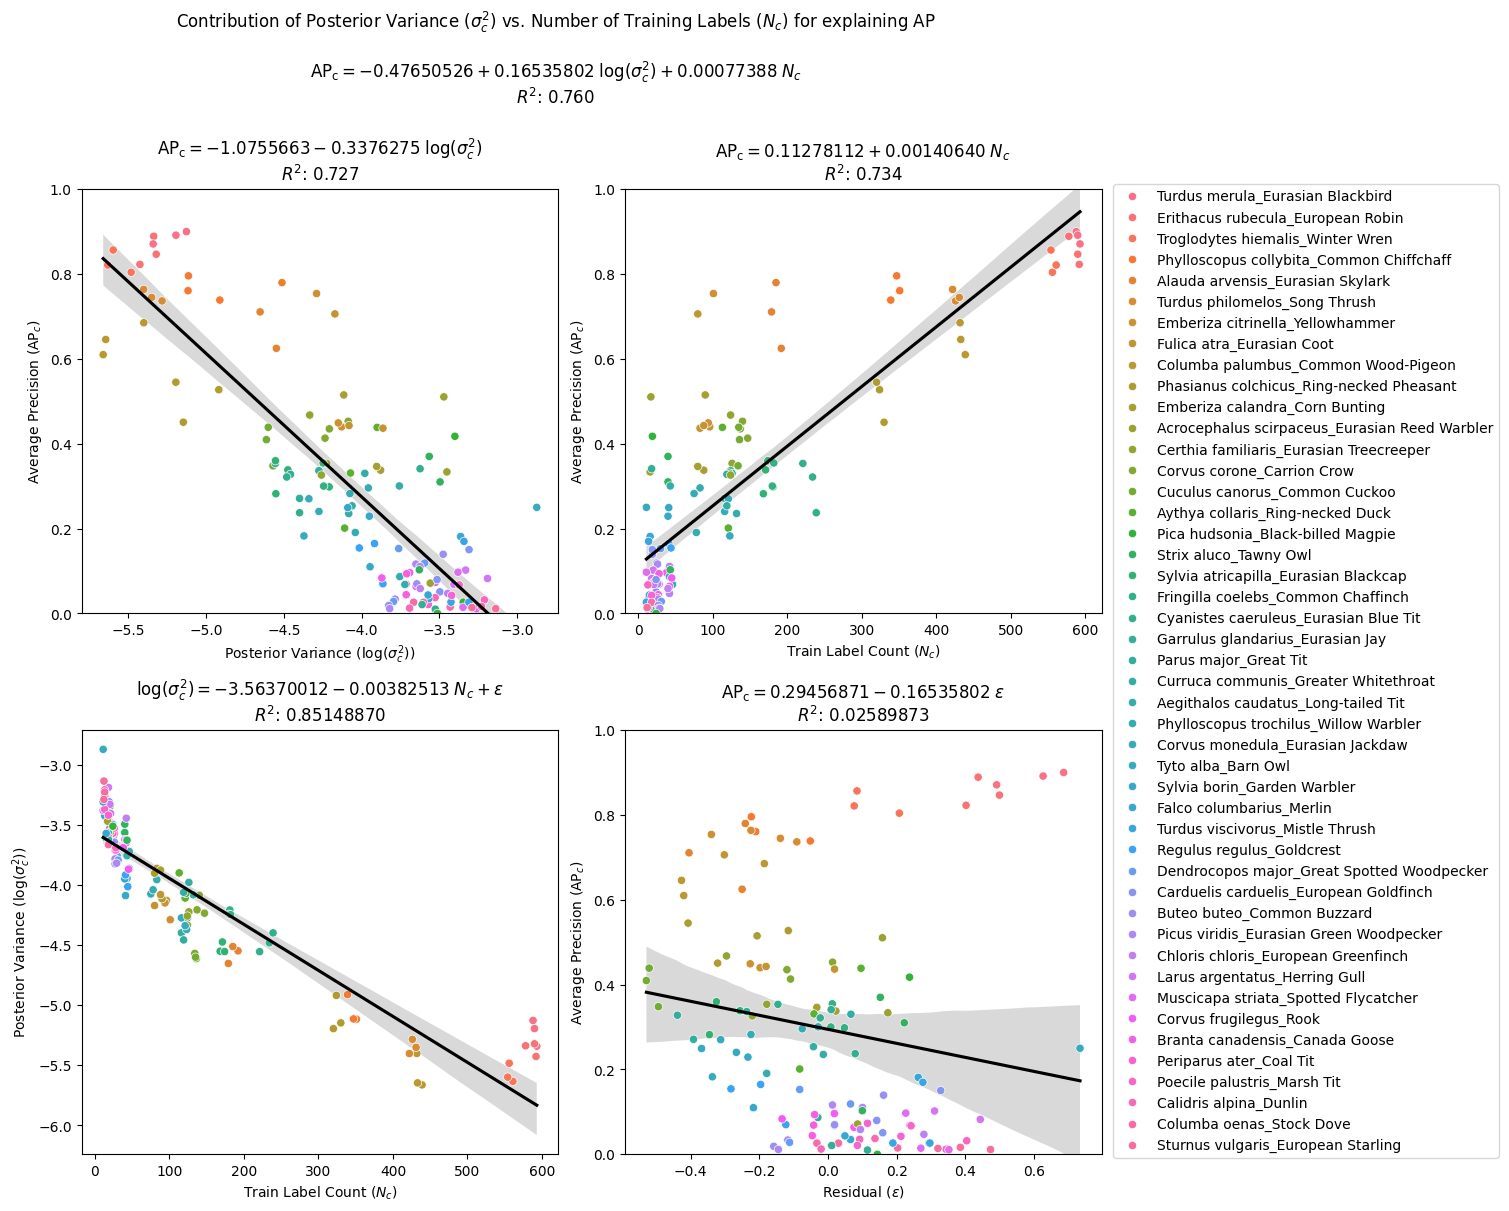

In [31]:
import pandas as pd
import pathlib
import rootutils
import torch
import tqdm
import numpy as np
import seaborn as sns
import colorcet as cc
import sklearn

np.random.seed(42)

rootutils.setup_root(".", indicator=".project-root", pythonpath=True)
root = pathlib.Path(rootutils.find_root("."))

from torch.nn import functional as F
from matplotlib import pyplot as plt

from src.core.data.soundscape_embeddings import SoundscapeEmbeddingsDataModule
from src.core.models.mil_species_detector import MILSpeciesDetector

scores_path = pathlib.Path("/its/home/kag25/experiments/v3/bayesian_species_detectors/scores")
model_path = pathlib.Path("/its/home/kag25/models/v3/bayesian_species_detectors/")

model_names = ["wanted-pencil", "eloquent-mammal", "strong-mask"]
scopes = ["SO_UK"]
model_dict = {
    scope: {
        model_name: MILSpeciesDetector.load_from_checkpoint(model_path / f"{model_name}_{scope}.ckpt")
        for model_name in model_names
    }
    for scope in scopes
}
scores = pd.read_parquet(scores_path / "val_scores.parquet")
scores = scores.drop([
    'run_id', 'seed',
    'attention', 'classifiers', 'clf_regulariser',
    'attn_regulariser', 'beta', 'gamma_clf', 'gamma_attn',
    'label_smoothing', 'clf_learning_rate', 'attn_learning_rate', 'epoch'
], axis=1)
scores = scores.iloc[scores["AP"].argsort()[::-1]]
order = scores.species_name.unique()

results = []
for scope in scopes:
    for model_name in model_names:
        model = model_dict[scope][model_name]
        data = list(zip(model.target_names, *model.classifiers.weight_log_var.exp().t().detach().cpu().numpy()))
        species_weight_var = pd.DataFrame(data=data, columns=["species_name", *[i for i in range(model.classifiers.weight_log_var.size(1))]])
        species_weight_var = species_weight_var.reset_index()
        df = scores[scores.model == model_name].merge(species_weight_var, on="species_name", how="inner").drop("index", axis=1)
        df = df.set_index(["species_name", "AP", "auROC", "train_label_counts", "model", "scope"])
        results.append(df)
df = pd.concat(results)
long_df = df.melt(var_name="weight_index", value_name="weight_var", ignore_index=False).reset_index()
long_df["weight_log_var"] = np.log(long_df["weight_var"])

fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, figsize=(8, 12))
sns.scatterplot(data=long_df, x="AP", hue="species_name", y="weight_log_var", hue_order=order, ax=ax1, marker=".")
sns.move_legend(ax1, "upper left", bbox_to_anchor=(1, 1))
sns.scatterplot(data=long_df, x="auROC", hue="species_name", y="weight_log_var", hue_order=order, ax=ax2, legend=False, marker=".")
sns.scatterplot(data=long_df, x="train_label_counts", hue="species_name", y="weight_log_var", hue_order=order, ax=ax3, legend=False, marker=".")
sns.move_legend(ax1, "upper left", bbox_to_anchor=(1, 1.05))
plt.show()

df1 = df.sum(axis=1).reset_index().rename(columns={0: "weight_var_sum"})
df1["log_label_counts"] = np.log(df1["train_label_counts"])
df1["log_weight_var_sum"] = np.log(df1["weight_var_sum"])
df1["neg_log_weight_var_sum"] = -np.log(df1["weight_var_sum"])
df1["log_AP"] = np.log(df1["AP"])
df1["log_auROC"] = np.log(df1["auROC"])

fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, figsize=(8, 12))
sns.scatterplot(data=df1, x="AP", hue="species_name", y="log_weight_var_sum", hue_order=order, ax=ax1, marker=".")
sns.move_legend(ax1, "upper left", bbox_to_anchor=(1, 1))
sns.scatterplot(data=df1, x="auROC", hue="species_name", y="log_weight_var_sum", hue_order=order, ax=ax2, legend=False, marker=".")
sns.scatterplot(data=df1, x="train_label_counts", hue="species_name", y="log_weight_var_sum", hue_order=order, ax=ax3, legend=False, marker=".")
sns.move_legend(ax1, "upper left", bbox_to_anchor=(1, 1))
plt.show()

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(11, 12), constrained_layout=True)

p = 8

X, y = df1[["neg_log_weight_var_sum", "train_label_counts"]], df1["AP"]
reg = sklearn.linear_model.LinearRegression()
reg.fit(X, y)
suptitle = (
    "Contribution of Posterior Variance ($\sigma_c^2$) vs. Number of Training Labels ($N_c$) for explaining AP\n\n"
    rf"$\mathrm{{AP_c}} = {np.format_float_positional(reg.intercept_, precision=p)} + "
    rf"{np.format_float_positional(reg.coef_[0], precision=p)}\;\log(\sigma_c^2) + "
    rf"{np.format_float_positional(reg.coef_[1], precision=p)}\;N_c$"
    "\n"
    rf"$R^2$: {np.format_float_positional(reg.score(X, y), precision=3)}"
    "\n"
)
print(suptitle)
fig.suptitle(suptitle)

# correlation between the posterior variance and the average precision
# how much of the variance in the scores is explained by the posterior variance
X, y = df1[["log_weight_var_sum"]], df1["AP"]
reg = sklearn.linear_model.LinearRegression()
reg.fit(X, y)
sns.regplot(data=df1, x="log_weight_var_sum", y="AP", ax=ax1, scatter=False, color="black")
sns.scatterplot(data=df1, x="log_weight_var_sum", y="AP", hue="species_name", ax=ax1, hue_order=order)
ax1.set_ylim(bottom=0, top=1)
title = (
    rf"$\mathrm{{AP_c}} = {np.format_float_positional(reg.intercept_, precision=p)}"
    rf"{np.format_float_positional(reg.coef_[0], precision=p)}\;\log(\sigma_c^2)$"
    "\n"
    rf"$R^2$: {np.format_float_positional(reg.score(X, y), precision=3)}"
)
print(title)
ax1.set_title(title)
ax1.set_xlabel(r"Posterior Variance ($\log(\sigma_c^2)$)")
ax1.set_ylabel(r"Average Precision ($\mathrm{AP}_c$)")

handles, labels = ax1.get_legend_handles_labels()
ax1.get_legend().remove()

# correlation between the label counts and the average precision
# how much of the variance in the scores is explained by the the number of training labels
X, y = df1[["train_label_counts"]], df1["AP"]
reg = sklearn.linear_model.LinearRegression()
reg.fit(X, y)
sns.regplot(data=df1, x="train_label_counts", y="AP", ax=ax2, scatter=False, color="black")
sns.scatterplot(data=df1, x="train_label_counts", y="AP", hue="species_name", ax=ax2, hue_order=order, legend=False)
ax2.set_ylim(bottom=0, top=1)

title = (
    rf"$\mathrm{{AP_c}} = {np.format_float_positional(reg.intercept_, precision=p)} +"
    rf"{np.format_float_positional(reg.coef_[0], precision=p)}\;N_c$"
    "\n"
    rf"$R^2$: {np.format_float_positional(reg.score(X, y), precision=3)}"
)
print(title)
ax2.set_title(title)
ax2.set_xlabel(r"Train Label Count ($N_c$)")
ax2.set_ylabel(r"Average Precision ($\mathrm{AP}_c$)")

# since it appears from comparing the first regression R2 with the previous two,
# it appears the number of labels explain most of the correlation.
# how much does the posterior variance actually contribute
X1, X2, y = df1[["train_label_counts"]], df1["log_weight_var_sum"], df1[["AP"]]
reg = sklearn.linear_model.LinearRegression()
reg.fit(X1, X2)
sns.regplot(data=df1, x="train_label_counts", y="log_weight_var_sum", ax=ax3, scatter=False, color="black")
sns.scatterplot(data=df1, x="train_label_counts", y="log_weight_var_sum", hue="species_name", ax=ax3, hue_order=order, legend=False)

title = (
    rf"$\log(\sigma_c^2) = {np.format_float_positional(reg.intercept_, precision=p)}"
    rf"{np.format_float_positional(reg.coef_[0], precision=p)}\;N_c + \epsilon$"
    "\n"
    rf"$R^2$: {np.format_float_positional(reg.score(X1, X2), precision=p)}"
)
print(title)
ax3.set_title(title)
ax3.set_xlabel(r"Train Label Count ($N_c$)")
ax3.set_ylabel(r"Posterior Variance ($\log(\sigma_c^2)$)")

df1["variance_residual"] = X2 - reg.predict(X1)
X3 = df1[["variance_residual"]]
reg = sklearn.linear_model.LinearRegression()
reg.fit(X3, y)
sns.regplot(data=df1, x="variance_residual", y="AP", ax=ax4, scatter=False, color="black")
sns.scatterplot(data=df1, x="variance_residual", y="AP", hue="species_name", ax=ax4, hue_order=order, legend=False)
title = (
    rf"$\mathrm{{AP_c}} = {np.format_float_positional(reg.intercept_, precision=p)}"
    rf"{np.format_float_positional(reg.coef_[0], precision=p)}\;\epsilon$"
    "\n"
    rf"$R^2$: {np.format_float_positional(reg.score(X3, y), precision=p)}"
)
print(title)
ax4.set_title(title)
ax4.set_xlabel(r"Residual ($\epsilon$)")
ax4.set_ylabel(r"Average Precision ($\mathrm{AP}_c$)")
ax4.set_ylim(bottom=0, top=1)

fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.445))

plt.savefig(root / "dump" / "posterior-variance-contribution.pdf", format="pdf")
plt.show()

Posterior weight variance exhibits a strong inverse relationship with classifier performance. However, this relationship was almost entirely explained by the number of training labels available for each class. After regressing posterior variance on label count, the residual uncertainty explained only 2.5% of the remaining variation in average precision, indicating that posterior variance primarily reflects the amount of training evidence rather than intrinsic class difficulty.